In [18]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
import time
import json
from triangular_transport.flows.flow_trainer import (
    KernelTrainer,
)

from triangular_transport.flows.interpolants import (
    trig_interpolant,
    trig_interpolant_der,
    linear_interpolant,
    linear_interpolant_der,
)
from triangular_transport.flows.loss_functions import kernel_vec_field_loss
from triangular_transport.kernels.kernel_tools import get_prod_gaussianRBF, vectorize_kfunc
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
)
plt.style.use("ggplot")

In [8]:
@jax.vmap
def sigmoid_interpolant(t: jnp.array, x1: jnp.array, x0: jnp.array):
    return (1 - sigmoid(t)) * x0 + sigmoid(t) * x1

def sigmoid(t: float) -> float:
    return jax.nn.sigmoid(7 * (t - 0.1)) # Changed this to 25

sigmoid_dot = jax.vmap(jax.grad(sigmoid))

@jax.vmap
def sigmoid_interpolant_der(t: np.array, x1: np.array, x0: np.array) -> np.array:
    return sigmoid_dot(t) * (x1 - x0)

In [10]:
from diffrax import Heun, ODETerm, SaveAt, PIDController, diffeqsolve
import equinox as eqx

def sample_trajectory_ODE(
    vmap_model,
    X0,
    solver=Heun(),
    saveat=SaveAt(dense=True),
    dt0=1e-2,
    max_steps=20000,
    tol=1e-2,
    ts=None,
):
    @eqx.filter_jit
    def dX_t(t, x, args):
        t_vec = jnp.ones((len(x), 1)) * t
        return vmap_model(jnp.hstack([t_vec, x]))

    t0, t1 = 0.0, 1.0
    terms = ODETerm(dX_t)

    if saveat.dense is True:
        sol = diffeqsolve(
            terms, solver, t0, t1, dt0=dt0, y0=X0, saveat=saveat, max_steps=max_steps,
        )
        eval_ts = ts if ts is not None else jnp.linspace(t0, t1, 100)
        trajectory = jax.vmap(sol.evaluate)(eval_ts)  # shape: (len(ts), nsamples, dim)
    else:
        stepsize_controller = PIDController(rtol=tol, atol=tol)
        sol = diffeqsolve(
            terms, solver, t0, t1, dt0=dt0, y0=X0, saveat=saveat,
            max_steps=max_steps, stepsize_controller=stepsize_controller,
        )
        trajectory = sol.ys  # shape: (len(ts), nsamples, dim)

    return trajectory, sol

In [116]:
best_hyperparams = {
    'lam_value': 0.001784240471,
    'gamma1': 0.0996334585856,
    'gamma2': 0.243442877083,
    'gamma3': 1.2982789204244
}

# Train the one model
train_dim = 50000
num_batches = 2000
key = random.key(seed=1)
key, key1 = random.split(key=key, num=2)
batch_size = 2000
num_pivots = 5000
lam = best_hyperparams["lam_value"]
print_every = 5000
yu_dimension = (1, 1)
target_data = inf_train_gen(data="banana", rng=None, batch_size=train_dim)
dim = yu_dimension[0] + yu_dimension[1]
def model():
    pass

In [117]:
gammas = {v: best_hyperparams[v] for v in best_hyperparams if "gamma" in v}
k = get_prod_gaussianRBF(**gammas)
kvv = vectorize_kfunc(k)

interpolant = linear_interpolant
interpolant_der = linear_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

In [118]:
velocity = KernelTrainer(
    target_density=None,
    model=model,
    optimizer=optax.adam(1e-5),
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=kernel_vec_field_loss,
    interpolant_args=interpolant_args,
    seed=43,
    yu_dimension=yu_dimension,
    cond=True,
)
velocity.train(
    x1_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    num_batches=num_batches,
    num_pivots=num_pivots,
    x0_data=None,
    lam=lam,
    k=k,
    num_M_iters=1,

);

Picking pivots through Partial Cholesky


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Performing Nyström approximation


  0%|          | 0/2000 [00:00<?, ?it/s]

In [119]:
nsamples_testj = 1000
u0_cond = jax.random.normal(key=key, shape=(nsamples_testj, 1))
x0j = jnp.hstack([target_data[:nsamples_testj, 0:1], u0_cond])

ts = jnp.linspace(0.0, 1.0, 100)
trajectory_j, sol = sample_trajectory_ODE(velocity.model, X0=x0j, ts=ts)

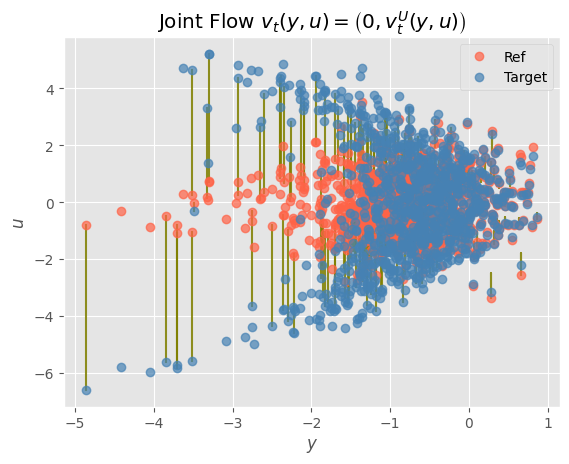

In [120]:
fig, ax = plt.subplots()
ax.plot(trajectory_j[:, :, 0][:, ::3], trajectory_j[:, :, 1][:, ::3], color="olive", alpha=0.87, lw=1.5)
ax.plot(x0j[:, 0], x0j[:, 1], linestyle="None", marker="o", markersize=6, color="tomato", alpha=0.7, label=r"Ref")
# ax[0].plot(x_train[:3000, 0], x_train[:3000, 1], linestyle="None", marker="o", markersize=6, color="tomato", alpha=0.7, label=r"Ref")
ax.plot(x0j[:, 0], trajectory_j[-1, :, 1], linestyle="None", marker="o", markersize=6, color="steelblue", alpha=0.7, label=r"Target")
ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$u$")
ax.set_title(r"Joint Flow $v_t(y, u) = \left(0, v_t^U(y, u)\right)$")
ax.legend()

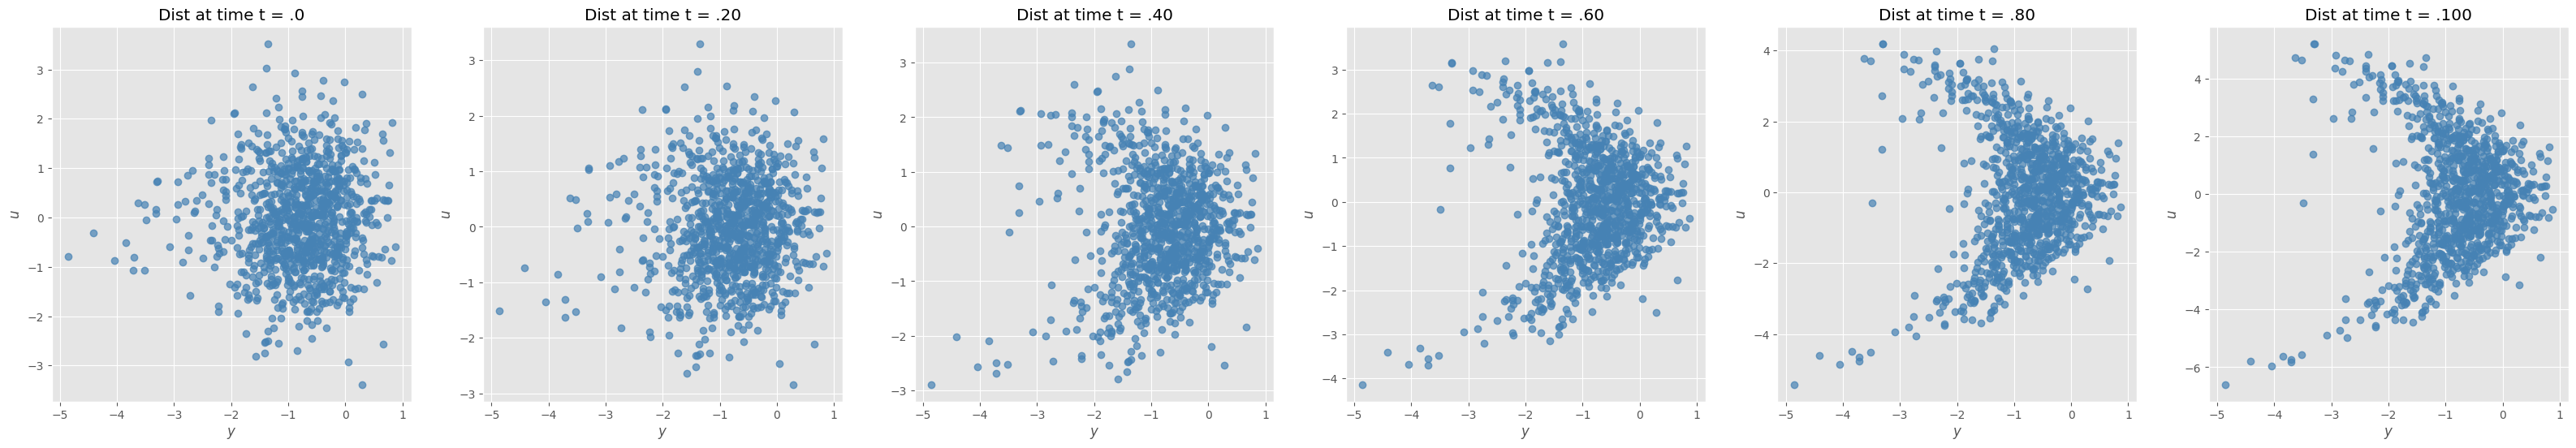

In [121]:
fig, ax = plt.subplots(1, 6, figsize=(40, 6))
t_idxs = [0, 20, 40, 60, 80, 100]
for i in range(6):
    ax[i].plot(trajectory_j[t_idxs[i], :, 0], trajectory_j[t_idxs[i], :, 1], linestyle="None", marker="o", markersize=6, color="steelblue", alpha=0.7)
    ax[i].set_title(f"Dist at time t = .{t_idxs[i]}")
    ax[i].set_xlabel(r"$y$")
    ax[i].set_ylabel(r"$u$")

In [122]:
cond_values = [0.0, -1.0, -5.0]
nsamples_test = 1000
u0_cond = jax.random.normal(key=key, shape=(nsamples_test, 1))
x0 = jnp.hstack([jnp.ones((nsamples_test, 1)) * cond_values[2], u0_cond])

ts = jnp.linspace(0.0, 1.0, 100)
trajectory, sol = sample_trajectory_ODE(velocity.model, X0=x0, ts=ts)

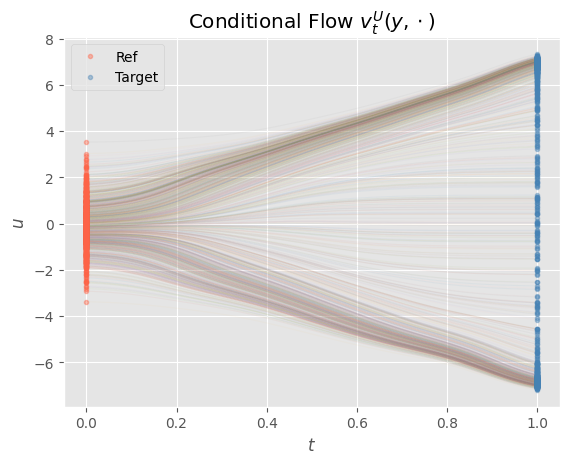

In [123]:
fig, ax = plt.subplots()
ax.plot(ts, trajectory[:, :, 1], alpha=0.05, lw=0.8)
ax.plot(np.zeros(nsamples_test), x0[:, 1], linestyle="None", marker="o", markersize=3, color="tomato", alpha=0.4, label=r"Ref")
ax.plot(np.ones(nsamples_test), trajectory[-1, :, 1], linestyle="None", marker="o", markersize=3, color="steelblue", alpha=0.4, label=r"Target")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$u$")
ax.set_title(r"Conditional Flow $v_t^U(y, \cdot)$")
ax.legend()